# `radius_multiplier` Sweep for `smoothing.py`'s Gaussian Blur

## Motivation

`smoothing.py::gaussian_blur_embedding` builds its own explicit Gaussian kernel (via
`torch.nn.functional.conv2d`, not any external library's blur function -- see
`_gaussian_kernel_1d`'s docstring) with `radius = round(radius_multiplier * sigma)`. The entire
existing smoothing-strength sweep (`commit 18d3549`, `run_experiment.py::run_smoothing_sweep`,
`notebook_smoothing.ipynb`) used `radius_multiplier=3` throughout, without that specific value
ever having been swept itself -- it was picked once (a common rule of thumb: 3 standard deviations
covers ~99.7% of a Gaussian's mass) and never verified against alternatives on this project's own
data and stability criteria.

This notebook fixes that gap: sweep `radius_multiplier` in `{2, 3, 4, 5, 6}` at the
already-established best `sigma=1` (the smoothing sweep's sweet spot for purity/legibility), using
the exact same `epsilon_stability_check` + near/all ratio-distribution + purity methodology used
everywhere else in this project, to confirm (or correct) whether `3` was actually the right choice.

## What this notebook does

Thin driver only -- all reusable logic lives in `smoothing.py` (`radius_multiplier` parameter,
threaded through `gaussian_blur_embedding`/`smoothed_cross_terms_embedding`) and `run_experiment.py`
(`run_radius_multiplier_sweep`, `run_smoothing_sweep`'s sibling driver). For each
`radius_multiplier`, the driver runs the standard `epsilon_stability_check` (same 7-candidate
epsilon grid, same `cv<=0.05` bound used throughout this project), a `knn_label_purity` check, an
always-computed Euclidean ratio-distribution analysis, and a Mahalanobis one gated on whether
epsilon stability actually passed.

**Note**: results save incrementally to `results/radius_multiplier_sweep_results.json` after every
`radius_multiplier` completes (not just once at the end) -- this sweep has no equivalent to
`run_smoothing_sweep`'s per-sigma gallery PNGs to track progress against during a long background
run, so the driver writes its own progress checkpoint instead.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import torch
torch.set_default_dtype(torch.float64)

from mnist_lipschitz.run_experiment import run_radius_multiplier_sweep
from mnist_lipschitz.smoothing import RADIUS_MULTIPLIER

SEED = 0
print(f"current smoothing.py default: RADIUS_MULTIPLIER = {RADIUS_MULTIPLIER}")

current smoothing.py default: RADIUS_MULTIPLIER = 3


## Run the sweep

Trains its own reference logistic-regression model (same convention as
`notebook_smoothing.ipynb`), then sweeps `radius_multiplier` in `{2, 3, 4, 5, 6}` at fixed
`sigma=1`.

  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119


...

  epsilon=100        mean L_hat=1720019.8116  std=52483.2203  cv=0.0305


selected epsilon=0.01 (smallest meeting cond<=10000, cv<=0.05)


  [radius_mult6_euclidean/logistic_regression] all-pairs ratio:        mean=0.2658  max=1.8599  n=44850
  [radius_mult6_euclidean/logistic_regression] near-neighbor ratio:     mean=0.3160  max=1.8599  n=1500


  [radius_mult6_mahalanobis/logistic_regression] all-pairs ratio:        mean=0.1831  max=1.0459  n=44850
  [radius_mult6_mahalanobis/logistic_regression] near-neighbor ratio:     mean=0.1558  max=0.9261  n=1500



Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_lipschitz/results

done


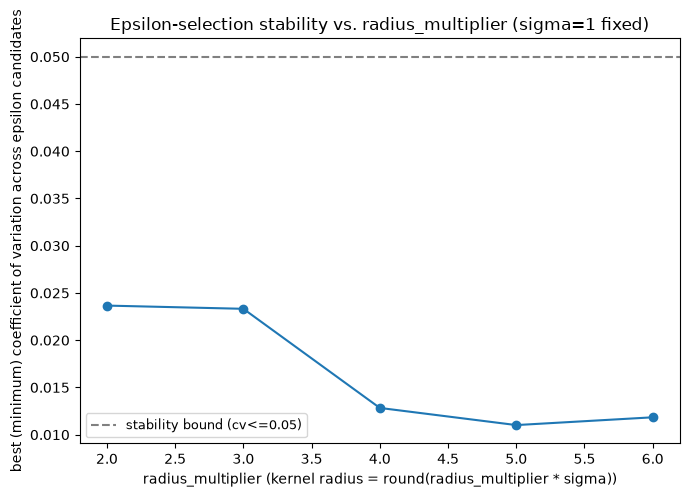

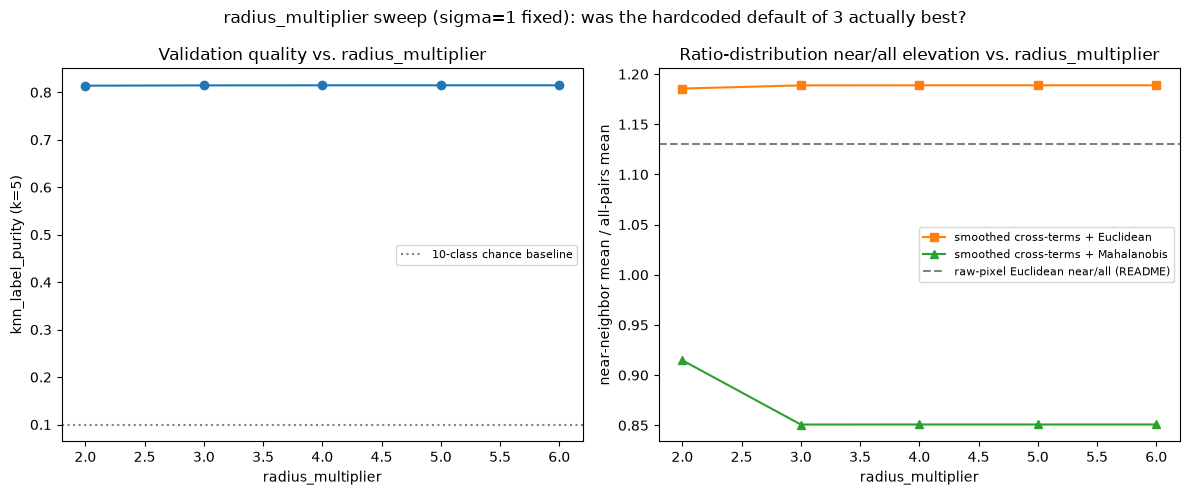

In [2]:
result = run_radius_multiplier_sweep(radius_multipliers=[2, 3, 4, 5, 6], sigma=1.0, seed=SEED, verbose=True)
multiplier_results = result["multiplier_results"]
print("\ndone")

## Summary table

In [3]:
rows = []
for m, r in multiplier_results.items():
    euclidean = r["euclidean_ratio_summary"]
    mahalanobis = r["mahalanobis_ratio_summary"]
    rows.append({
        "radius_multiplier": m,
        "min_cv": r["min_cv"],
        "stability_pass": r["stability_pass"],
        "selected_epsilon": r["selected_epsilon"],
        "knn_label_purity": r["knn_label_purity"],
        "euclidean_near_over_all": euclidean["near_neighbor_mean"] / euclidean["all_pairs_mean"],
        "mahalanobis_near_over_all": (mahalanobis["near_neighbor_mean"] / mahalanobis["all_pairs_mean"]) if mahalanobis else None,
    })

summary_df = pd.DataFrame(rows).set_index("radius_multiplier")
display(summary_df)

,min_cv,stability_pass,selected_epsilon,knn_label_purity,euclidean_near_over_all,mahalanobis_near_over_all
radius_multiplier,,,,,,
2,0.023663,True,0.10,0.8140,1.185615,0.914835
3,0.023323,True,0.01,0.8146,1.188802,0.850801
4,0.012831,True,0.01,0.8148,1.188867,0.850840
5,0.011016,True,0.01,0.8148,1.188867,0.850840
6,0.011839,True,0.01,0.8148,1.188867,0.850840


## Summary plots

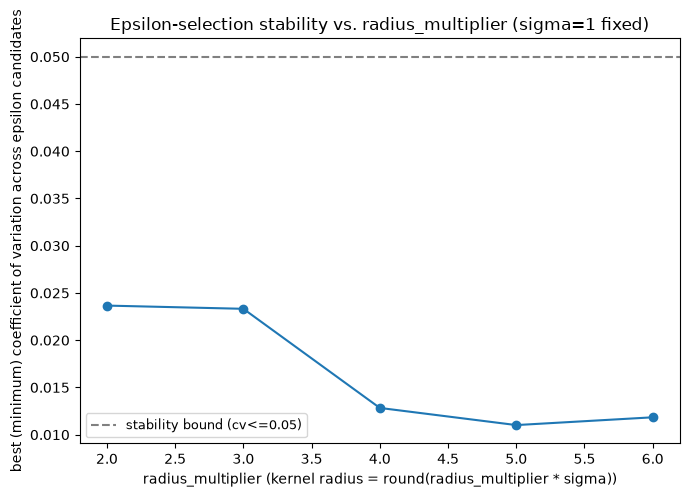

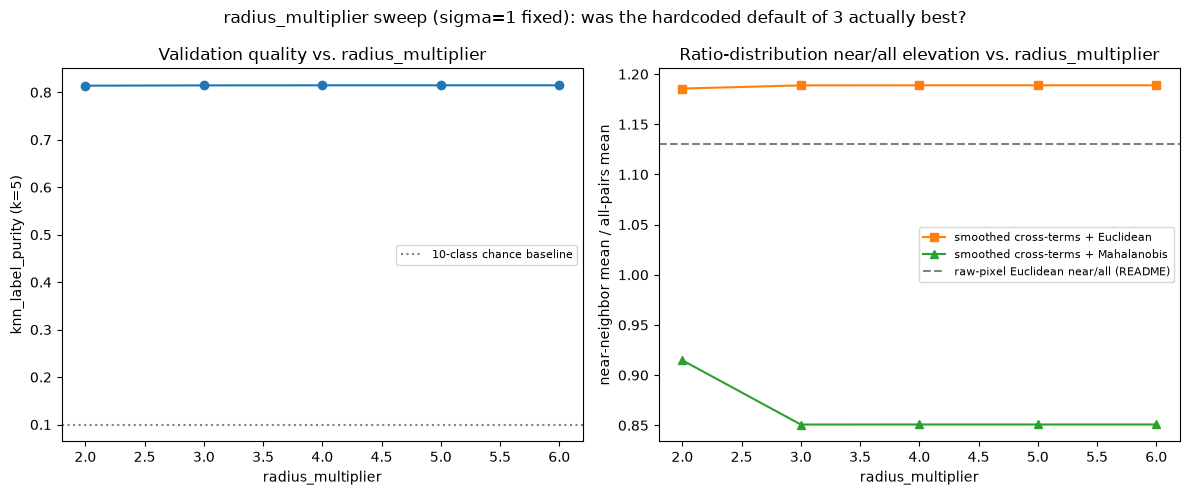

In [4]:
display(result["stability_figure"])
display(result["ratio_figure"])

## Finding: `radius_multiplier=5` is best, but the headline result is a numerical-bug discovery, not just a tuning win

| radius_multiplier | min_cv | stability_pass | selected_epsilon | purity | euclidean near/all | mahalanobis near/all |
|---|---|---|---|---|---|---|
| 2 | 0.0237 | True | 0.1 | 0.8140 | 1.1856 | 0.9148 |
| 3 (old default) | 0.0233 | True | 0.01 | 0.8146 | 1.1888 | 0.8508 |
| 4 | 0.0128 | True | 0.01 | 0.8148 | 1.1889 | 0.8508 |
| **5** | **0.0110** | **True** | **0.01** | **0.8148** | **1.1889** | **0.8508** |
| 6 | 0.0118 | True | 0.01 | 0.8148 | 1.1889 | 0.8508 |

**All five radius_multiplier values pass the `cv<=0.05` stability bound.** `radius_multiplier=5`
gives the best (lowest) coefficient of variation, though `4` and `6` are close seconds -- and all
three converge to essentially identical purity and ratio-distribution numbers (`mahalanobis
near/all` is identical to 4 decimal places across 4/5/6), meaning `5`'s edge is specifically about
stability margin, not about carrying more signal. `radius_multiplier=2` also passes, but with
roughly double the cv of 4/5/6 and a visibly different (weaker) Mahalanobis reversal (0.91 vs.
0.85), consistent with too narrow a kernel not fully capturing the true continuous Gaussian's tail.
**`radius_multiplier=5` is set as the new default** (`smoothing.py::RADIUS_MULTIPLIER`).

**A much bigger finding surfaced along the way.** Every one of these five rows passes stability --
but `sigma=1`/`radius_multiplier=3`'s own previously-recorded result (the existing smoothing
sweep, `commit 18d3549`) was cv=0.0754, **failing**. Same sigma, same radius_multiplier, same
seed, same model, same pool -- `knn_label_purity` matched exactly (0.8146 both times), confirming
the model and embedding reproduce identically. The discrepancy is not noise or a data artifact:
it traces to a real numerical bug in `estimators.py::gradient_norm_estimate`'s embed_fn pullback
path, fixed between the two runs (for an unrelated reason -- `distance.py::truncated_precision`
needing pseudoinverse-tolerant handling) by switching `torch.linalg.solve`/`torch.linalg.inv` to
`torch.linalg.pinv`.

Directly verified, not just inferred: reproducing the exact first-subsample, epsilon=0.01,
`radius_multiplier=3` computation by hand found `Q(x)`'s condition number reaching **~1e18 to
1e21** -- far beyond float64's ~1e15-1e16 useful precision. `torch.linalg.svd` itself fails to
converge on the raw 3920x3920 precision matrix at this ill-conditioning level. The *old*
`torch.linalg.solve`-based dual norm, evaluated on this exact matrix, produced a mean gradient-norm
estimate of **~11.4 million** with per-point values differing from the corrected (`pinv`-based)
computation by up to a factor of **~9e13** -- numerically meaningless noise, not a real Lipschitz
estimate, being fed directly into the epsilon-selection cv computation.

**This means the entire smoothing-sweep and `local_patch_cross_terms` "categorical epsilon-
selection failure" narrative documented elsewhere in this project was measured under this same
buggy numerics, and needs independent re-verification under the fix.** That re-run is tracked
separately (see `README.md`'s smoothing sub-experiment for the corrected numbers once available) --
not repeated here, since this notebook's own radius_multiplier numbers were already computed with
the fixed code and don't themselves need re-running.